# Densification Analysis of Stochastic Quantum Trajectories

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3D
import matplotlib.animation as animation

from numba import njit
from numba import complex128 as ncomplex

import os

%matplotlib widget

## Function

In [2]:
# ── Bloch sphere helpers ───────────────────────────────────────────────────

sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

def bloch_coords(rho):
    """Bloch vector (x,y,z) from a 2x2 density matrix."""
    x = np.real(np.trace(rho @ sigma_x))
    y = np.real(np.trace(rho @ sigma_y))
    z = np.real(np.trace(rho @ sigma_z))
    return np.array([x, y, z])

@njit
def NJIT_bloch_coords(rho):
    x = np.real(np.trace(rho @ np.array([[0, 1], [1, 0]], dtype=ncomplex)))
    y = np.real(np.trace(rho @ np.array([[0, -1j], [1j, 0]], dtype=ncomplex)))
    z = np.real(np.trace(rho @ np.array([[1, 0], [0, -1]], dtype=ncomplex)))
    return x, y, z

@njit
def NJIT_vectors_inCartesian_coords(many_rho_trjs, t_idx):
    """Estrae i vettori di Bloch di tutte le traiettorie all'indice temporale t_idx."""
    n_traj = many_rho_trjs.shape[0]
    vects = np.empty((3, n_traj))
    for i in range(n_traj):
        rho = many_rho_trjs[i, t_idx]
        x, y, z = NJIT_bloch_coords(rho)
        vects[0, i] = x
        vects[1, i] = y
        vects[2, i] = z
    return vects

@njit
def NJIT_angle_between_vectors(u, v):
    dot, nu, nv = 0.0, 0.0, 0.0
    for i in range(3):
        dot += u[i] * v[i]
        nu  += u[i] * u[i]
        nv  += v[i] * v[i]
    cos_t = dot / (np.sqrt(nu) * np.sqrt(nv))
    cos_t = max(-1.0, min(1.0, cos_t))
    return np.arccos(cos_t)

@njit
def NJIT_mean_angle_bruteforce(many_rho_trjs, t_idx, norm=np.pi):
    """Angolo medio (normalizzato) tra tutte le coppie di traiettorie al tempo t_idx."""
    av_angle = 0.0
    c = 0
    n = many_rho_trjs.shape[0]
    vects = NJIT_vectors_inCartesian_coords(many_rho_trjs, t_idx)
    for i in range(n):
        for j in range(i + 1, n):
            av_angle += NJIT_angle_between_vectors(vects[:, i], vects[:, j])
            c += 1
    return (av_angle / (c * norm)) if c > 0 else 0.0

@njit
def NJIT_syncr_measure_time(many_rho_trjs, norm=np.pi/2, minusone=True):
    """
    Misura di densificazione nel tempo.

    Parameters
    ----------
    many_rho_trjs : ndarray, shape (N_traj, N_time, 2, 2)
    norm          : normalizzazione angoli (default pi/2 → misura in [0,1])
    minusone      : se True restituisce 1-angolo (1=sincronizzate)
                    se False restituisce l'angolo medio (0=sincronizzate)

    Returns
    -------
    ndarray, shape (N_time,)
    """
    ntime = many_rho_trjs.shape[1]
    out   = np.zeros(ntime)
    for i in range(ntime):
        a = NJIT_mean_angle_bruteforce(many_rho_trjs, i, norm)
        out[i] = (1.0 - a) if minusone else a
    return out

## Non Markovian Measure -- Le ignoro ??

In [3]:
# # ── Misure non-Markoviane (da nonmarkov.py) ────────────────────────────────

# def finite_diff_gradient(y, x):
#     """Gradiente a differenze finite di y rispetto a x."""
#     g = np.zeros_like(y)
#     g[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])
#     g[0]    = (y[1]  - y[0])   / (x[1]  - x[0])
#     g[-1]   = (y[-1] - y[-2])  / (x[-1] - x[-2])
#     return g

# def get_positive_part(y):
#     """Azzera i valori negativi di y."""
#     return np.where(y > 0, y, 0.0)

# def integrate_on_positive_part(x, y):
#     """
#     Integra la parte positiva di y su x.
#     Restituisce (integrale_totale, integrale_cumulativo_in_tempo).
#     """
#     pos_y = get_positive_part(y)
#     integral_t = np.cumsum(pos_y * np.diff(x, prepend=x[0]))
#     return integral_t[-1], integral_t

# def resynchronization_measure(syncr_meas, time_stepped):
#     """
#     Calcola la misura di risincronizzazione dalla misura di densificazione.
#     Integra solo i tratti in cui la densificazione sta aumentando.
#     """
#     rate   = finite_diff_gradient(syncr_meas, time_stepped)
#     pos    = get_positive_part(rate)
#     total, in_time = integrate_on_positive_part(time_stepped, pos)
#     return total, in_time, rate

## Data Load

In [4]:
# ====================================
# Physical & Simulation Parameters
# ====================================
# Theta angle in degrees, H_Coll Direction
theta_target_deg = 60.0  # change angle here
theta_rad = np.radians(theta_target_deg)

# Site selector: 0 for |10>, 1 for |01>
site_index = 0

# Time step
dt = 0.01

# Number of trajectories to analyze
N_traj_to_plot = 100         

# =================
# Input Data Setup
# =================
Input_dir = "../../Results/Data/Complete_rho/normal"  # <-- change here if needed

# Format theta and dt for filename 
theta_str = f"{theta_rad:.6f}".replace(".", "p")
dt_str = f"{dt:.6f}".replace(".", "p")

# File name
filename = f"result_theta{theta_str}_dt{dt_str}_Ntraj20000.npz"
filepath = os.path.join(Input_dir, filename)

print(f"Analisi impostata per theta = {theta_target_deg}°")
print(f"File target: {filename}")

if not os.path.exists(filepath):
    print(f"ERRORE: The file {filepath} doesn't exist. Check file name.")
else:
    # Load .npz input containing data
    data = np.load(filepath)
    
    times= data['times']

    # Define a downsampling factor (e.g., take 1 every 10 time steps)
    time_downsample_factor = 10
    
    # Downsample the time array
    time_stepped = times[::time_downsample_factor]
    N_time = len(time_stepped)
    
    print("Matrix extraction and downsampling in progress")
    
    # ================================
    # Raw Trajectories Extraction
    # ================================
    
    # Extract the full time array
    full_times = data['times']
    
    # Extract and downsample the raw trajectories along the time axis (axis 0)
    # Then transpose (.T) to get the expected (N_traj, N_time) shape
    pop_traj_10 = data['pop_00'][::time_downsample_factor, :].T
    pop_traj_01 = data['pop_11'][::time_downsample_factor, :].T
    
    cohe_traj_10_01 = data['coh_10_01'][::time_downsample_factor, :].T
    cohe_traj_01_10 = data['coh_01_10'][::time_downsample_factor, :].T

    # Extract real and imaginary parts of the coherence
    rho12_re = np.real(cohe_traj_10_01)
    rho12_im = np.imag(cohe_traj_10_01)
    
    # Map populations to density matrix diagonal elements
    rho11 = pop_traj_10
    rho22 = pop_traj_01

    print("Data extraction completed")

# ── Ricostruzione delle matrici densità 2x2 ──────────────────────────────
#
#   rho = [[rho11,        rho12_re + i*rho12_im],
#           [rho12_re - i*rho12_im, rho22       ]]
#
N_traj, N_time = rho11.shape

many_rho = np.zeros((N_traj, N_time, 2, 2), dtype=complex)
many_rho[:, :, 0, 0] =  rho11
many_rho[:, :, 1, 1] =  rho22
many_rho[:, :, 0, 1] =  rho12_re + 1j * rho12_im
many_rho[:, :, 1, 0] =  rho12_re - 1j * rho12_im

print(f"Shape many_rho: {many_rho.shape}")
print(f"Esempio rho[traj=0, t=0]:\n{many_rho[0,0]}")
print(f"Traccia (deve essere ~1): {np.real(np.trace(many_rho[0,0])):.4f}")

Analisi impostata per theta = 60.0°
File target: result_theta1p047198_dt0p010000_Ntraj20000.npz
Matrix extraction and downsampling in progress
Data extraction completed
Shape many_rho: (20000, 1000, 2, 2)
Esempio rho[traj=0, t=0]:
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Traccia (deve essere ~1): 1.0000


In [5]:
# ===========================
# General Setup for Plotting
# ===========================
# --- 1. Output Directory---

if theta_target_deg.is_integer():
    angle_folder = str(int(theta_target_deg))
else:
    angle_folder = str(theta_target_deg)

Output_dir = os.path.join("../../Results/Plot/Densification", angle_folder)
os.makedirs(Output_dir, exist_ok=True)

# --- 2. Global Style Settings (Matplotlib rcParams) ---
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# --- 3. Automatic Figure Saving Function ---
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

In [6]:
# ── Helper: disegna la sfera di Bloch su un asse 3D ───────────────────────
def setup_bloch_sphere(ax, xylabels=True):
    u = np.linspace(0, 2*np.pi, 60)
    v = np.linspace(0, np.pi, 30)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(x, y, z, color='gray', linewidth=0.3, alpha=0.4, rstride=5, cstride=5)
    for axis in [[1,0,0],[0,1,0],[0,0,1]]:
        ax.plot([-axis[0],axis[0]],[-axis[1],axis[1]],[-axis[2],axis[2]], color='grey', lw=0.8, alpha=0.5)
    if xylabels:
        ax.text(1.2,0,0,"x",fontsize=11); ax.text(0,1.2,0,"y",fontsize=11)
    ax.text(0,0,1.25,r"$|0\rangle$",fontsize=13); ax.text(0,0,-1.35,r"$|1\rangle$",fontsize=13)
    ax.set_xlim([-1.1,1.1]); ax.set_ylim([-1.1,1.1]); ax.set_zlim([-1.1,1.1])
    ax.set_box_aspect([1,1,1]); ax.set_axis_off()

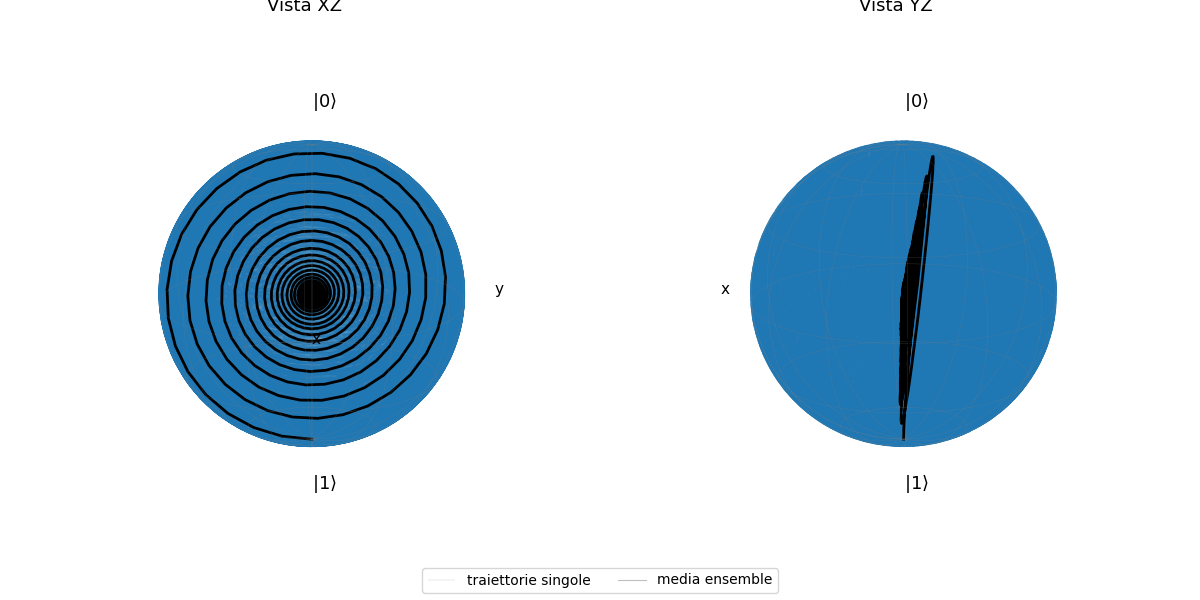

In [7]:
# ── Plot ensemble di traiettorie (due viste) ──────────────────────────────
fig = plt.figure(figsize=(12, 6))
for col, (elev, azim, title) in enumerate([(15, 0, 'Vista XZ'), (15, 90, 'Vista YZ')]):
    ax = fig.add_subplot(1, 2, col+1, projection='3d')
    setup_bloch_sphere(ax)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title)
    for i in range(N_traj_to_plot):
        bv = np.array([bloch_coords(many_rho[i, t]) for t in range(N_time)])
        ax.plot(bv[:,0], bv[:,1], bv[:,2], alpha=0.15, color='C0', lw=1)
    # media ensemble
    rho_av = np.mean(many_rho, axis=0)   # shape (N_time, 2, 2)
    bv_av  = np.array([bloch_coords(rho_av[t]) for t in range(N_time)])
    ax.plot(bv_av[:,0], bv_av[:,1], bv_av[:,2], color='k', lw=2, label='media')

fig.legend(['traiettorie singole','media ensemble'], loc='lower center', ncol=2)
plt.tight_layout()
plt.show()

## Densification Measure

In [8]:
# norm=pi/2 → la misura è in [0,1]
# minusone=False → output = angolo medio (0 = traiettorie sovrapposte)
# con minusone=True  → output = 1 - angolo medio (1 = traiettorie sovrapposte)

# Define how many trajectories to use for the synchronization measure
# 1000 trajectories = ~500,000 pairs (400 times faster than 20,000!)
N_traj_sync = 1000

# Pass only the sliced array to the function
BF_syncr_meas = NJIT_syncr_measure_time(
    many_rho[:N_traj_sync],
    norm     = np.pi / 2,
    minusone = False
)

print(f"Measure calculated on {N_time} time steps, {N_traj_sync} trajectories.")
print(f"Initial value: {BF_syncr_meas[0]:.4f}   Final value: {BF_syncr_meas[-1]:.4f}")

Measure calculated on 1000 time steps, 1000 trajectories.
Initial value: 0.0000   Final value: 0.9997


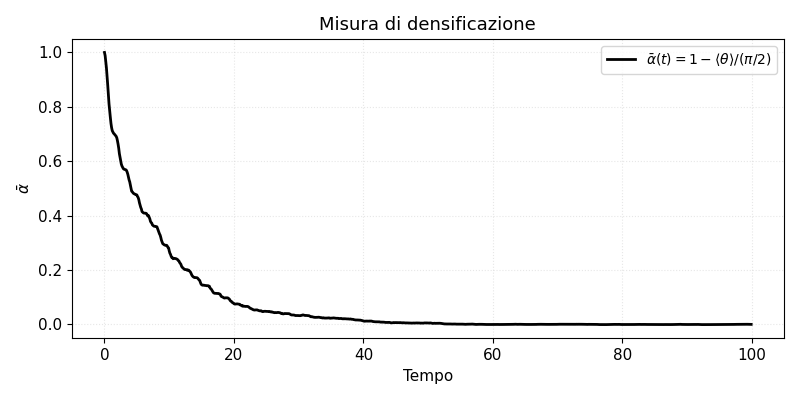

In [9]:
# ── Plot densificazione nel tempo ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_stepped, 1 - BF_syncr_meas, color='k', lw=2, label=r'$\bar{\alpha}(t) = 1 - \langle\theta\rangle / (\pi/2)$')
ax.set_xlabel('Tempo')
ax.set_ylabel(r'$\bar{\alpha}$')
ax.set_title('Misura di densificazione')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Misura di risincronizzazione (non-Markoviana)

In [10]:
# # Integra i tratti in cui la densificazione AUMENTA (risincronizzazione)
# # Analogo alla misura BLP ma per le traiettorie stocastiche

# total_resync, resync_in_time, rate = resynchronization_measure(BF_syncr_meas, time_stepped)

# print(f"Misura di risincronizzazione totale: {total_resync:.6f}")

In [11]:
# fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# axes[0].plot(time_stepped, BF_syncr_meas, 'k', lw=1.5)
# axes[0].set_title('Angolo medio normalizzato'); axes[0].set_xlabel('Tempo')
# axes[0].set_ylabel(r'$\langle\theta\rangle / (\pi/2)$'); axes[0].grid(alpha=0.3)

# axes[1].plot(time_stepped, rate, color='steelblue', lw=1.5)
# axes[1].axhline(0, color='k', lw=0.8, linestyle='--')
# axes[1].fill_between(time_stepped, rate, 0, where=(rate > 0), alpha=0.3, color='green', label='risincronizzazione')
# axes[1].fill_between(time_stepped, rate, 0, where=(rate < 0), alpha=0.3, color='red',   label='desincronizzazione')
# axes[1].set_title('Tasso di variazione'); axes[1].set_xlabel('Tempo')
# axes[1].set_ylabel(r"$d\bar{\alpha}/dt$"); axes[1].legend(); axes[1].grid(alpha=0.3)

# axes[2].plot(time_stepped, resync_in_time, color='green', lw=2)
# axes[2].set_title(f'Risincronizzazione cumulativa\nTotale = {total_resync:.4f}')
# axes[2].set_xlabel('Tempo'); axes[2].set_ylabel('Integrale'); axes[2].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

## SVD Bloch Vectors

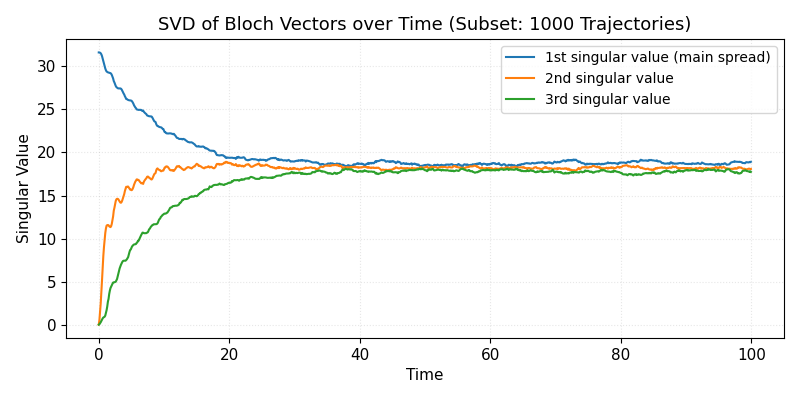

In [12]:
# Define the number of trajectories to use for the SVD analysis
N_traj_svd = 1000  # Change this value to your desired sample size

sing_vals = []
for t in range(N_time):
    # Extract Bloch vectors ONLY for the specified subset of trajectories
    # many_rho[:N_traj_svd] slices the first N_traj_svd elements along axis 0
    vects = NJIT_vectors_inCartesian_coords(many_rho[:N_traj_svd], t_idx=t)  # shape (3, N_traj_svd)
    
    # Perform SVD using compute_uv=False to avoid memory overflow (RAM crash)
    # It only computes and returns the singular values (S)
    S = np.linalg.svd(vects, compute_uv=False)
    sing_vals.append(S)

# Convert the list to a NumPy array for plotting
sing_vals = np.array(sing_vals)  # shape (N_time, 3)

# ── Plot SVD Singular Values ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

labels_sv = ['1st singular value (main spread)',
             '2nd singular value',
             '3rd singular value']

# Loop through the 3 singular values and plot their time evolution
for k in range(3):
    ax.plot(time_stepped, sing_vals[:, k], label=labels_sv[k])

ax.set_xlabel('Time')
ax.set_ylabel('Singular Value')
ax.set_title(f'SVD of Bloch Vectors over Time (Subset: {N_traj_svd} Trajectories)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## GIF animation

GIF saved successfully at: ../../Results/Plot/Densification/60/bloch_animation_theta1p047198.gif


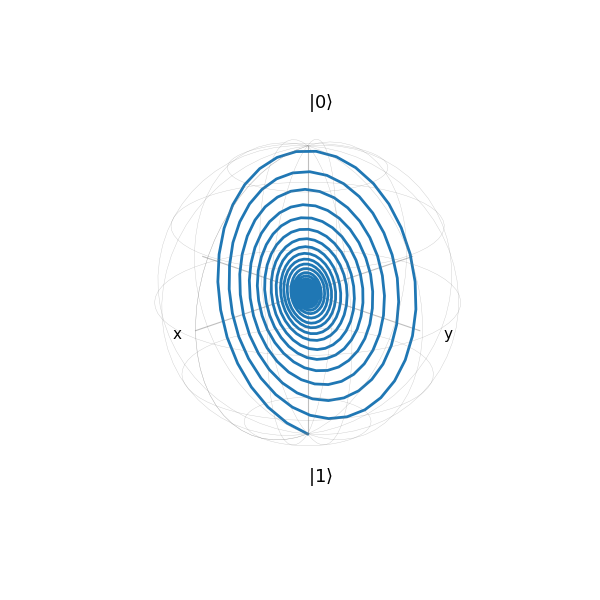

In [13]:
# ── GIF traiettoria media ─────────────────────────────────────────────────

rho_av = np.mean(many_rho, axis=0)   # (N_time, 2, 2)
coords = np.array([bloch_coords(rho_av[t]) for t in range(N_time)])
xs, ys, zs = coords[:,0], coords[:,1], coords[:,2]

fig = plt.figure(figsize=(6,6))
ax  = fig.add_subplot(111, projection='3d')
setup_bloch_sphere(ax)
ax.view_init(elev=20, azim=45)

path_line, = ax.plot([], [], [], color='C0', lw=2)
arrow = ax.quiver(0,0,0,0,0,0, color='C0', arrow_length_ratio=0.15, linewidth=2)

def update(frame):
    global arrow
    path_line.set_data(xs[:frame], ys[:frame])
    path_line.set_3d_properties(zs[:frame])
    arrow.remove()
    arrow = ax.quiver(0,0,0, xs[frame],ys[frame],zs[frame],
                      color='C0', arrow_length_ratio=0.15, linewidth=2)
    return path_line, arrow

ani = animation.FuncAnimation(fig, update, frames=N_time, blit=False)

# Define the path for the GIF using the output directory and theta parameter
gif_filename = f"bloch_animation_theta{theta_str}.gif"
gif_path = os.path.join(Output_dir, gif_filename)

# Save the animation to the specific path
ani.save(gif_path, writer='pillow', fps=20)

print(f"GIF saved successfully at: {gif_path}")
plt.show()

